In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gaussxw import gaussxwab
from math import gamma
from scipy.special import zeta

In [2]:
N=700
u, w = gaussxwab(N,0,1)

def g(z, n):
    f = lambda x: x**(n-1)/(np.exp(x)/z-1) / gamma(n)
    h = lambda u: 1/(1-u)**2 * f(u/(1-u))
    I = np.sum(w*h(u))
    return I

g = np.vectorize(g)

In [3]:
def biseccion(f, a, b, tol):
    err = 2*tol
    
    while err > tol:
        x_med = (a+b)/2
        if f(a)*f(x_med)>0: # Estoy en el intervalo de a, me he pasado por la izq. --> recorto a=x_med
            a=x_med
        else:
            b=x_med
        err = np.abs(b-a)
        
    return (b+a)/2

In [4]:
h = 6.626e-34
kB = 1.38e-23
c = 3e8
N = 1e23
V = 1

T_c = h*c/(2*kB) * (N/V)**(1/3) * (np.pi*zeta(3))**(-1/3)

def z(T):
    # Hay que resolver g3(z)=(T_c/T)**3 * zeta(3)
    f = lambda z: g(z, 3)-(T_c/T)**3*zeta(3)
    z = biseccion(f, 0,1,1e-4)
    return z

z = np.vectorize(z)

/tmp/ipykernel_9679/1475806866.py:5: RuntimeWarning: overflow encountered in exp
  f = lambda x: x**(n-1)/(np.exp(x)/z-1) / gamma(n)
/tmp/ipykernel_9679/1475806866.py:5: RuntimeWarning: divide by zero encountered in divide
  f = lambda x: x**(n-1)/(np.exp(x)/z-1) / gamma(n)
/tmp/ipykernel_9679/1475806866.py:5: RuntimeWarning: overflow encountered in divide
  f = lambda x: x**(n-1)/(np.exp(x)/z-1) / gamma(n)


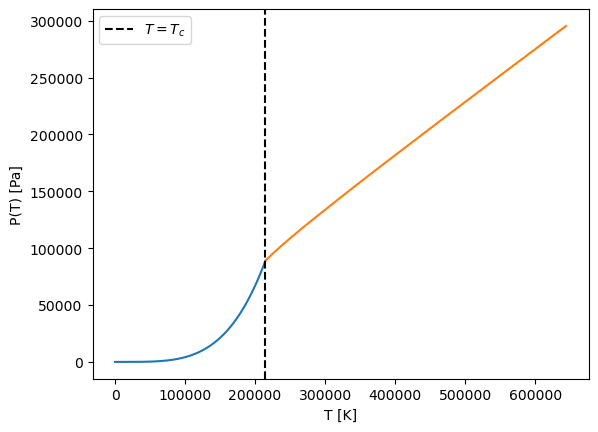

In [5]:
P0 = lambda T: 8*np.pi*zeta(4)*kB**4*T**4 / (3*c**3*h**3) # T<T_c
P1 = lambda T: 8*np.pi*g(z(T), 4)*kB**4*T**4 / (3*c**3*h**3) # T>T_c
T0 = np.linspace(0,T_c, 500)
T1 = np.linspace(T_c, 3*T_c, 700)

plt.plot(T0, P0(T0))
plt.plot(T1, P1(T1))
plt.axvline(T_c, linestyle="dashed", color="black", label="$T=T_c$")
plt.xlabel("T [K]")
plt.ylabel("P(T) [Pa]")
plt.legend()
plt.show()

/tmp/ipykernel_9679/1475806866.py:5: RuntimeWarning: overflow encountered in exp
  f = lambda x: x**(n-1)/(np.exp(x)/z-1) / gamma(n)
/tmp/ipykernel_9679/1475806866.py:5: RuntimeWarning: divide by zero encountered in divide
  f = lambda x: x**(n-1)/(np.exp(x)/z-1) / gamma(n)
/tmp/ipykernel_9679/1475806866.py:5: RuntimeWarning: overflow encountered in divide
  f = lambda x: x**(n-1)/(np.exp(x)/z-1) / gamma(n)


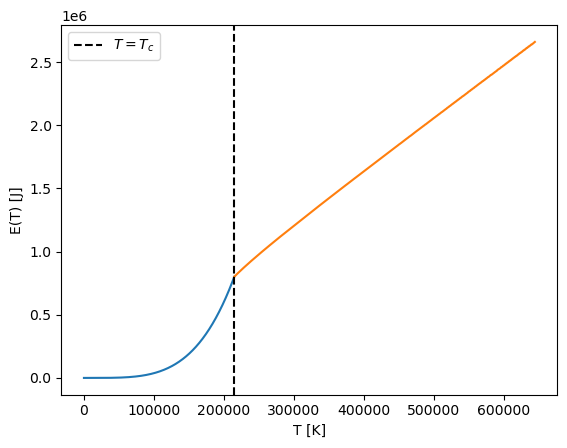

In [6]:
E0 = lambda T: 24*np.pi*V*kB**4*T**4*zeta(4) / (c**3*h**3)
E1 = lambda T: 24*np.pi*V*kB**4*T**4*g(z(T),4) / (c**3*h**3)

E0 = E0(T0)
E1 = E1(T1)

plt.plot(T0, E0)
plt.plot(T1, E1)
plt.axvline(T_c, linestyle="dashed", color="black", label="$T=T_c$")
plt.legend()
plt.xlabel("T [K]")
plt.ylabel("E(T) [J]")
plt.show()

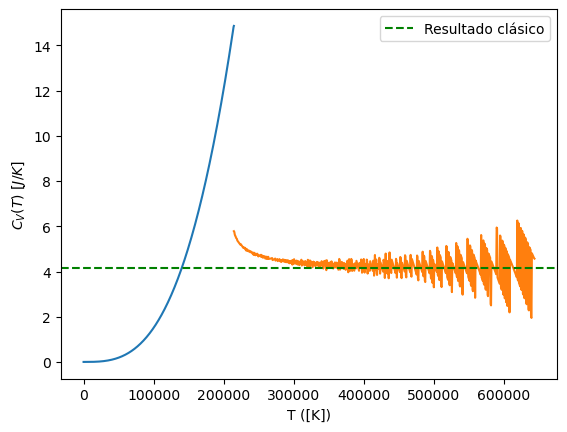

In [8]:
h0 = T0[1]-T0[0]
h1 = T1[1]-T1[0]

C_V0 = np.empty_like(E0)
C_V0[1:-1] = (E0[2:]-E0[:-2])/(2*h0)
C_V0[0] = (E0[1]-E0[0])/h0
C_V0[-1] = (E0[-1]-E0[-2])/h0

C_V1 = np.empty_like(E1)
C_V1[1:-1] = (E1[2:]-E1[:-2])/(2*h1)
C_V1[0] = (E1[1]-E1[0])/h1
C_V1[-1] = (E1[-1]-E1[-2])/h1

plt.plot(T0, C_V0)
plt.plot(T1, C_V1)
plt.axhline(3*N*kB, linestyle="dashed", color="green", label="Resultado clásico")
plt.xlabel("T ([K])")
plt.ylabel("$C_V (T) \\ [J/K]$")
plt.legend()
plt.show()

In [48]:
for i in T1:
    print(i)

214670.3038571283
215746.34548047232
216822.38710381632
217898.42872716032
218974.47035050433
220050.5119738483
221126.5535971923
222202.5952205363
223278.63684388032
224354.67846722432
225430.72009056833
226506.76171391233
227582.80333725634
228658.84496060034
229734.88658394432
230810.92820728832
231886.96983063233
232963.01145397633
234039.05307732034
235115.09470066434
236191.13632400834
237267.17794735235
238343.21957069635
239419.26119404036
240495.30281738433
241571.34444072834
242647.38606407234
243723.42768741635
244799.46931076035
245875.51093410436
246951.55255744836
248027.59418079234
249103.63580413634
250179.67742748035
251255.71905082435
252331.76067416836
253407.80229751236
254483.84392085637
255559.88554420037
256635.92716754437
257711.96879088838
258788.01041423238
259864.0520375764
260940.09366092036
262016.13528426437
263092.1769076084
264168.21853095235
265244.26015429635
266320.30177764036
267396.34340098436
268472.38502432837
269548.4266476724
270624.4682710164
2

In [50]:
print(len(T1))

400
